<a href="https://colab.research.google.com/github/Chandana14314/student-score-prediction/blob/main/StudentScorePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [321]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [322]:
df = pd.read_csv("/content/score.csv")

df

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


In [323]:
df.shape

(25, 2)

In [324]:
X = df[['Hours']]
y = df['Scores']

In [325]:
X

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [326]:
y

,Scores
0,21
1,47
2,27
3,75
4,30
5,20
6,88
7,60
8,81
9,25


In [327]:
import sklearn
import numpy
from sklearn.model_selection import train_test_split

In [328]:
X_train , X_test , y_train , y_test =train_test_split(X , y , test_size=0.3 , random_state=42)

In [329]:
len(X_train) , len(y_train) # training data

(17, 17)

In [330]:
len(X_test) , len(y_test) #testing data

(8, 8)

In [331]:
# for training data Excel
training_data = pd.DataFrame({'X_train':X_train.to_numpy().ravel() , 'y_train':y_train})
training_data


,X_train,y_train
22,3.8,35
5,1.5,20
2,3.2,27
12,4.5,41
15,8.9,95
3,8.5,75
4,3.5,30
20,2.7,30
17,1.9,24
21,4.8,54


In [332]:
#for testing data
testing_data = pd.DataFrame({'X_test': X_test.to_numpy().ravel() , 'y_test':y_test})
testing_data

,X_test,y_test
8,8.3,81
16,2.5,30
0,2.5,21
23,6.9,76
11,5.9,62
9,2.7,25
13,3.3,42
1,5.1,47


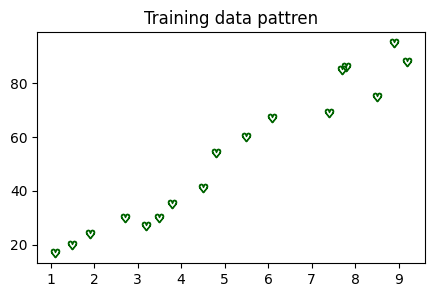

In [333]:
#training data pattren
plt.figure(figsize=(5,3))
plt.title('Training data pattren')
plt.scatter(x = X_train , y = y_train , color = 'darkgreen' , marker = "$\\heartsuit$")
plt.show()

In [334]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()


In [335]:
reg.fit(X_train , y_train)    #y = mx+c m =sumation i=1-->n each point of x - mean of x * each point of y -mean of y divided by xi- men of x **2

LinearRegression()

In [336]:
reg.coef_ #m value

array([9.71054094])

In [337]:
reg.intercept_ #c value

np.float64(2.794196676599803)

In [338]:
sat_ans = reg.predict(X_train)

In [339]:
training_data['Saturday_ans'] = sat_ans

In [340]:
training_data

,X_train,y_train,Saturday_ans
22,3.8,35,39.694252
5,1.5,20,17.360008
2,3.2,27,33.867928
12,4.5,41,46.491631
15,8.9,95,89.218011
3,8.5,75,85.333795
4,3.5,30,36.781090
20,2.7,30,29.012657
17,1.9,24,21.244224
21,4.8,54,49.404793


`Training Performance`

`To find Accuracy  r2_Score  = 1 -  sumation of i to n actual points of y - predicted points of y **2 /actual point of y - mean of y **2`

`1 - (yi - ycap )**2 / (y - ybar)**2`

`loss(error , residual) = Actual point - predicted point  y - ycap`

`mean-Square-error= sumation of i = 1 to n yi - y cap whole square / n-1`



In [341]:
numerator = 0
denominator = 0

for i in training_data.index:
  numerator = numerator + (training_data['y_train'][i] - training_data['Saturday_ans'][i])
  denominator = denominator + (training_data['y_train'][i] - training_data['y_train'].mean())**2

print(f'numerator : {numerator}')
print(f'denominator : {denominator}')

numerator : 3.375077994860476e-14
denominator : 11515.764705882353


In [342]:
1 - numerator / denominator

np.float64(1.0)

In [343]:
from sklearn.metrics import r2_score
print(f'Training data performance : {r2_score(y_train , sat_ans)}')

Training data performance : 0.9536486503889446


In [344]:
#loss = Actual point y - predicted point y^
len(training_data)

17

In [345]:
numerator = 0

for i in training_data.index:
  numerator = numerator + (training_data['y_train'][i] - training_data['Saturday_ans'][i])**2

print(numerator / len(training_data) - 1)

30.398307995353253


In [346]:
from sklearn.metrics import mean_squared_error
print(f'Training Loss :{mean_squared_error(y_train , sat_ans)}')

Training Loss :31.398307995353253


In [347]:
from sklearn.metrics import root_mean_squared_error

print(f'Training Loss :{root_mean_squared_error(y_train , sat_ans)}')

Training Loss :5.603419312826166


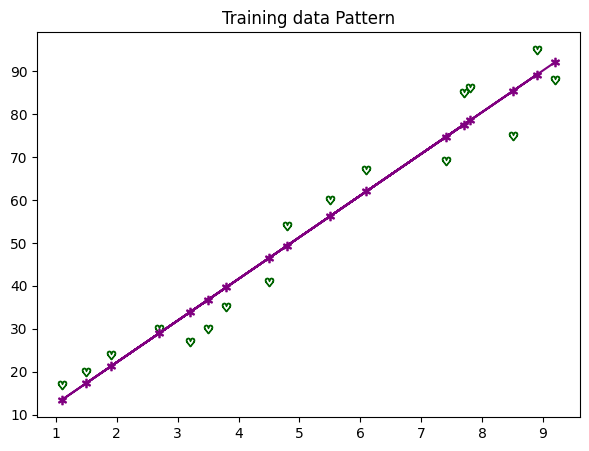

In [348]:
#training Data Pattern

plt.figure(figsize=(7,5))
plt.title('Training data Pattern')
plt.scatter(x = X_train , y = y_train , color ='darkgreen' , marker = '$\\heartsuit$')
plt.plot(X_train , sat_ans , marker= '$\\ast$' , color = 'purple')
plt.show()

`Testing data performance`


In [349]:
testing_data

,X_test,y_test
8,8.3,81
16,2.5,30
0,2.5,21
23,6.9,76
11,5.9,62
9,2.7,25
13,3.3,42
1,5.1,47


In [350]:
result_sat = reg.predict(X_test)
result_sat

array([83.39168645, 27.07054902, 27.07054902, 69.79692914, 60.0863882 ,
       29.0126572 , 34.83898177, 52.31795545])

In [351]:
testing_data['saturday_ans'] = result_sat
testing_data

,X_test,y_test,saturday_ans
8,8.3,81,83.391686
16,2.5,30,27.070549
0,2.5,21,27.070549
23,6.9,76,69.796929
11,5.9,62,60.086388
9,2.7,25,29.012657
13,3.3,42,34.838982
1,5.1,47,52.317955


In [352]:
print(f'Test Accuracy:{r2_score(y_test , result_sat)}')

Test Accuracy:0.9487647340257012


In [353]:
print(f'Test Loss : {root_mean_squared_error(y_test , result_sat)}')

Test Loss : 4.859985351228103


`My model performance was : : 94.87`

In [354]:
import warnings
warnings.filterwarnings("ignore")

`Own Data Point`

In [355]:
reg.predict([[15]])[0]

np.float64(148.45231072276383)